# S&P 500 Data Pipeline
This notebook builds a leakage-safe dataset for S&P 500 stocks by combining market prices with publication-dated fundamentals.

In [5]:
import wrds
import pandas as pd

db = wrds.Connection(
    wrds_username='gavriilk',
    connect_args={
        'connect_timeout': 30,
        'keepalives': 1,
        'keepalives_idle': 60,
        'keepalives_interval': 10,
        'keepalives_count': 5,
    }
)

Loading library list...
Done


## 1) Universe Definition
Create the stock universe: all companies that have been in the S&P 500 at least once.

In [6]:
# Ticker symbol history for S&P500 companies only (that were at least once in S&P500)
ticker_history = db.raw_sql("""
    SELECT DISTINCT
        n.permno       AS stock_id,
        n.ticker       AS ticker_symbol,
        n.comnam       AS company_name,
        n.namedt       AS ticker_entry_date,
        n.nameendt     AS ticker_exit_date
    FROM crsp.msenames n
    WHERE EXISTS (
        SELECT 1 FROM crsp.msp500list s 
        WHERE s.permno = n.permno
    )
    ORDER BY n.permno, n.namedt;
""")

ticker_history['ticker_entry_date'] = pd.to_datetime(ticker_history['ticker_entry_date'])
ticker_history['ticker_exit_date'] = pd.to_datetime(ticker_history['ticker_exit_date'])

print(f"Total records: {len(ticker_history)}")
print(f"Unique stock IDs (S&P500 companies): {ticker_history['stock_id'].nunique()}")

Total records: 10223
Unique stock IDs (S&P500 companies): 1936


## 2) Universe Diagnostics
Inspect how many S&P 500 stock IDs are active through time and visualize membership dynamics.

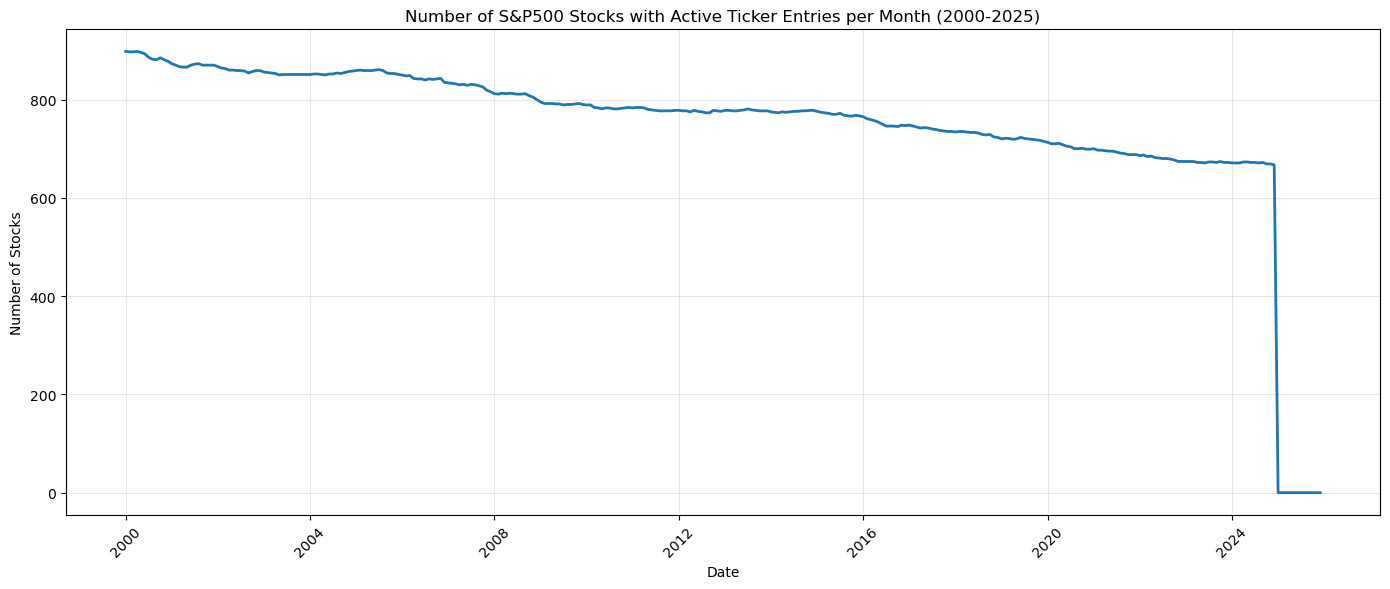

Min stocks: 0
Max stocks: 898
Latest count: 0


In [7]:
# Count unique stock_ids active per month
import numpy as np

# Create monthly dates from 2000 to end of 2025
months = pd.date_range(start='2000-01-01', end='2025-12-31', freq='MS')

# For each month, count stocks with active ticker entries
monthly_counts = []

for month_start in months:
    # End of month
    month_end = month_start + pd.DateOffset(months=1) - pd.DateOffset(days=1)
    
    # Count distinct stock_ids active during this month
    # A stock is active if: ticker_entry_date <= month_end AND (ticker_exit_date IS NULL OR ticker_exit_date >= month_start)
    active = ticker_history[
        (ticker_history['ticker_entry_date'] <= month_end) &
        ((ticker_history['ticker_exit_date'].isna()) | (ticker_history['ticker_exit_date'] >= month_start))
    ]['stock_id'].nunique()
    
    monthly_counts.append({'date': month_start, 'num_stocks': active})

monthly_stocks = pd.DataFrame(monthly_counts)

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 6))
plt.plot(monthly_stocks['date'], monthly_stocks['num_stocks'], linewidth=2)
plt.title('Number of S&P500 Stocks with Active Ticker Entries per Month (2000-2025)')
plt.xlabel('Date')
plt.ylabel('Number of Stocks')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Min stocks: {monthly_stocks['num_stocks'].min()}")
print(f"Max stocks: {monthly_stocks['num_stocks'].max()}")
print(f"Latest count: {monthly_stocks['num_stocks'].iloc[-1]}")

## 3) Market Data Extraction
Pull monthly CRSP price/return data and keep a market-data publication date for each observation.

In [8]:
# Price and return data for a given list of stock_ids / tickers.
# For CRSP monthly market data, the observation becomes available on the trading date itself.
# Keeping an explicit publication date column makes it easier to avoid leakage downstream.
selected_stock_ids = ticker_history['stock_id'].unique()
start_date = '2005-01-01'
end_date = '2025-12-31'

price_query = f"""
    SELECT
        a.permno AS stock_id,
        n.ticker AS ticker_symbol,
        a.date AS market_data_publication_date,
        a.ret AS monthly_return,
        a.prc AS price,
        a.vol AS volume
    FROM crsp.msf a
    JOIN crsp.msenames n
      ON a.permno = n.permno
     AND a.date BETWEEN n.namedt AND COALESCE(n.nameendt, '9999-12-31')
    WHERE a.date BETWEEN '{start_date}' AND '{end_date}'
      AND (
            a.permno IN ({','.join(str(stock_id) for stock_id in selected_stock_ids)})
      )
    ORDER BY stock_id
"""

price_with_publication = db.raw_sql(price_query)
price_with_publication['market_data_publication_date'] = pd.to_datetime(price_with_publication['market_data_publication_date'])

print(price_with_publication.head(10))

   stock_id ticker_symbol market_data_publication_date  monthly_return  price  \
0     10078          SUNW                   2005-01-31       -0.191095   4.36   
1     10078          SUNW                   2005-02-28        -0.03211   4.22   
2     10078          SUNW                   2005-03-31       -0.042654   4.04   
3     10078          SUNW                   2005-04-29        -0.10396   3.62   
4     10078          SUNW                   2005-05-31        0.052486   3.81   
5     10078          SUNW                   2005-06-30       -0.020997   3.73   
6     10078          SUNW                   2005-07-29        0.029491   3.84   
7     10078          SUNW                   2005-08-31       -0.010417    3.8   
8     10078          SUNW                   2005-09-30        0.034211   3.93   
9     10078          SUNW                   2005-10-31        0.017812    4.0   

       volume  
0  12908024.0  
1   6955359.0  
2   9256622.0  
3   8407687.0  
4   6554317.0  
5  11123281.

## 4) Market Coverage Checks
Validate data availability over time and explain differences in stock counts across periods.

In [9]:
price_with_publication.groupby('stock_id').agg(
    first_date=('market_data_publication_date', 'min'),
    last_date=('market_data_publication_date', 'max'),
    num_records=('market_data_publication_date', 'count')
).reset_index()

,stock_id,first_date,last_date,num_records
0,10078,2005-01-31,2009-12-31,60
1,10104,2005-01-31,2024-12-31,240
2,10107,2005-01-31,2024-12-31,240
3,10108,2005-01-31,2005-07-29,7
4,10137,2005-01-31,2011-01-31,73
...,...,...,...,...
1041,93159,2012-05-31,2020-07-31,99
1042,93246,2010-02-26,2024-12-31,179
1043,93422,2010-07-30,2021-02-26,128
1044,93429,2010-06-30,2024-12-31,175


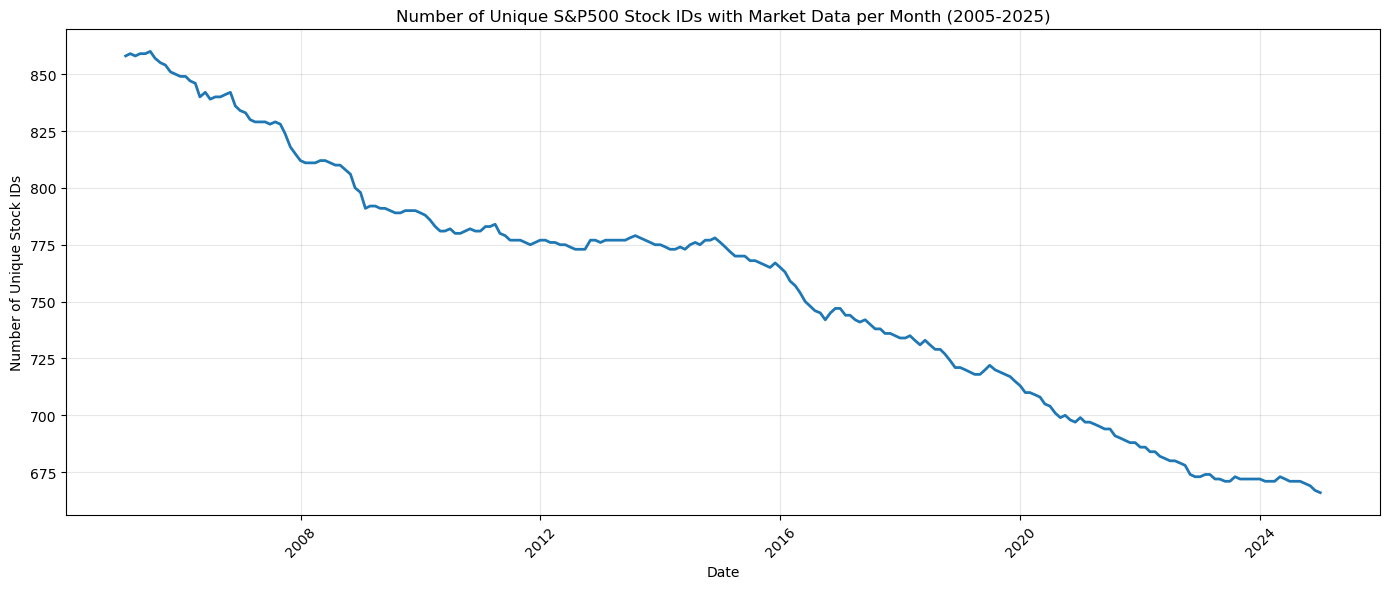

In [10]:
# Number of stock IDS in sp500 per month (should be around 500, but can be less due to missing data or delistings)
monthly_stock_counts = price_with_publication.groupby('market_data_publication_date')['stock_id'].nunique().reset_index(name='num_stocks')
plt.figure(figsize=(14, 6))
plt.plot(monthly_stock_counts['market_data_publication_date'], monthly_stock_counts['num_stocks'], linewidth=2)
plt.title('Number of Unique S&P500 Stock IDs with Market Data per Month (2005-2025)')
plt.xlabel('Date')
plt.ylabel('Number of Unique Stock IDs')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# Investigate why stock count is declining
# Total unique stocks in selected_stock_ids but with NO data in price_with_publication
total_selected = len(selected_stock_ids)
stocks_with_data = price_with_publication['stock_id'].nunique()
stocks_no_data = total_selected - stocks_with_data

print(f"Total S&P500 constituents (all-time): {total_selected}")
print(f"Stocks with price data (2005-2025): {stocks_with_data}")
print(f"Stocks with NO price data: {stocks_no_data}")

# Check for data gaps: stocks that had data early but disappeared
first_month = price_with_publication['market_data_publication_date'].min()
last_month = price_with_publication['market_data_publication_date'].max()

stocks_early = price_with_publication[price_with_publication['market_data_publication_date'] < '2010-01-01']['stock_id'].nunique()
stocks_late = price_with_publication[price_with_publication['market_data_publication_date'] >= '2020-01-01']['stock_id'].nunique()

print(f"\nStocks with data before 2010: {stocks_early}")
print(f"Stocks with data after 2020: {stocks_late}")
print(f"Loss from early to late: {stocks_early - stocks_late} stocks")

# List some stocks that disappeared (had data before 2010 but not after 2020)
stocks_before_2010 = price_with_publication[price_with_publication['market_data_publication_date'] < '2010-01-01']['stock_id'].unique()
stocks_after_2020 = price_with_publication[price_with_publication['market_data_publication_date'] >= '2020-01-01']['stock_id'].unique()
disappeared = set(stocks_before_2010) - set(stocks_after_2020)

print(f"\nExample stocks that disappeared: {list(disappeared)[:10]}")

Total S&P500 constituents (all-time): 1936
Stocks with price data (2005-2025): 1046
Stocks with NO price data: 890

Stocks with data before 2010: 917
Stocks with data after 2020: 732
Loss from early to late: 185 stocks

Example stocks that disappeared: [np.int64(23552), np.int64(26112), np.int64(38914), np.int64(91650), np.int64(86021), np.int64(91143), np.int64(25099), np.int64(88587), np.int64(83981), np.int64(75789)]


## 5) Fundamentals with Publication Date
Load Compustat quarterly fundamentals and keep the actual publication date to avoid look-ahead bias.

In [12]:
# Fundamentals with actual earnings announcement date (rdq) as the publication date.
# - datadate : end of the fiscal quarter (when the period closed)
# - rdq      : actual date the earnings were publicly announced (true publication date)
# Using rdq as the publication date prevents look-ahead / data leakage:
# a feature computed from these fundamentals must only be used AFTER rdq.

# Link CRSP permno → Compustat gvkey via the CRSP-Compustat Merged (CCM) link table
fundamentals_query = f"""
    SELECT
        lnk.lpermno                     AS stock_id,
        fq.gvkey                        AS company_id,
        fq.tic                          AS ticker_symbol,
        fq.datadate                     AS fiscal_quarter_end_date,
        fq.rdq                          AS publication_date,
        fq.atq                          AS total_assets,
        fq.ltq                          AS total_liabilities,
        fq.ceqq                         AS shareholders_equity,
        fq.niq                          AS net_income,
        fq.revtq                        AS revenue,
        fq.oibdpq                       AS operating_income_before_depreciation,
        fq.dlttq                        AS long_term_debt
    FROM comp.fundq fq
    JOIN crsp.ccmxpf_lnkhist lnk
      ON lnk.gvkey = fq.gvkey
     AND fq.datadate BETWEEN lnk.linkdt AND COALESCE(lnk.linkenddt, '9999-12-31')
     AND lnk.linktype IN ('LC', 'LU', 'LX')
     AND lnk.linkprim IN ('P', 'C')
    WHERE lnk.lpermno IN ({','.join(str(s) for s in selected_stock_ids)})
      AND fq.rdq IS NOT NULL
      AND fq.datadate BETWEEN '{start_date}' AND '{end_date}'
      AND fq.indfmt = 'INDL'
      AND fq.datafmt = 'STD'
      AND fq.popsrc = 'D'
      AND fq.consol = 'C'
    ORDER BY stock_id, publication_date
"""

fundamentals_with_publication = db.raw_sql(fundamentals_query)
fundamentals_with_publication['fiscal_quarter_end_date'] = pd.to_datetime(fundamentals_with_publication['fiscal_quarter_end_date'])
fundamentals_with_publication['publication_date'] = pd.to_datetime(fundamentals_with_publication['publication_date'])

# Average lag between quarter end and publication
lag = (fundamentals_with_publication['publication_date'] - fundamentals_with_publication['fiscal_quarter_end_date']).dt.days
print(f"Rows: {len(fundamentals_with_publication)}")
print(f"Unique stocks: {fundamentals_with_publication['stock_id'].nunique()}")
print(f"Avg days from quarter-end to publication: {lag.mean():.0f} days")
print(fundamentals_with_publication.head(10))

Rows: 62371
Unique stocks: 1034
Avg days from quarter-end to publication: 30 days
   stock_id company_id ticker_symbol fiscal_quarter_end_date publication_date  \
0   10078.0     012136        JAVA.1              2005-03-31       2005-04-14   
1   10078.0     012136        JAVA.1              2005-06-30       2005-07-26   
2   10078.0     012136        JAVA.1              2005-09-30       2005-11-01   
3   10078.0     012136        JAVA.1              2005-12-31       2006-01-24   
4   10078.0     012136        JAVA.1              2006-03-31       2006-04-24   
5   10078.0     012136        JAVA.1              2006-06-30       2006-07-25   
6   10078.0     012136        JAVA.1              2006-09-30       2006-10-26   
7   10078.0     012136        JAVA.1              2006-12-31       2007-01-23   
8   10078.0     012136        JAVA.1              2007-03-31       2007-04-24   
9   10078.0     012136        JAVA.1              2007-06-30       2007-07-30   

   total_assets  total_lia

## 6) Point-in-Time Merge
Merge prices with the latest available fundamentals at each date, then compute key financial ratios.

In [13]:
# Point-in-time merge: for each monthly price observation, attach the MOST RECENTLY
# published fundamentals as of that date (publication_date <= market_data_publication_date).
# This version merges PER STOCK_ID to avoid global sorting issues in merge_asof.

# --- Prepare price side ---
price_sorted = price_with_publication.copy()
price_sorted['market_data_publication_date'] = pd.to_datetime(price_sorted['market_data_publication_date'])
price_sorted['stock_id'] = pd.to_numeric(price_sorted['stock_id'], errors='coerce')
price_sorted = price_sorted.dropna(subset=['stock_id', 'market_data_publication_date'])
price_sorted['stock_id'] = price_sorted['stock_id'].astype('int64')

# --- Prepare fundamentals side ---
fund_cols = [
    'stock_id', 'publication_date',
    'fiscal_quarter_end_date',
    'total_assets', 'total_liabilities', 'shareholders_equity',
    'net_income', 'revenue', 'operating_income_before_depreciation', 'long_term_debt'
]
fund_sorted = fundamentals_with_publication[fund_cols].copy()
fund_sorted['publication_date'] = pd.to_datetime(fund_sorted['publication_date'])
fund_sorted['stock_id'] = pd.to_numeric(fund_sorted['stock_id'], errors='coerce')
fund_sorted = fund_sorted.dropna(subset=['stock_id', 'publication_date'])
fund_sorted['stock_id'] = fund_sorted['stock_id'].astype('int64')

# --- Point-in-time merge per stock_id ---
merged_parts = []
for sid, p_grp in price_sorted.groupby('stock_id', sort=False):
    p_grp = p_grp.sort_values('market_data_publication_date')
    f_grp = fund_sorted[fund_sorted['stock_id'] == sid].sort_values('publication_date')

    if f_grp.empty:
        # Keep price rows even if no fundamentals exist for this stock
        merged_parts.append(p_grp.copy())
        continue

    part = pd.merge_asof(
        p_grp,
        f_grp,
        left_on='market_data_publication_date',
        right_on='publication_date',
        direction='backward'
    )

    # merge_asof on each group keeps both stock_id columns when not using `by`
    if 'stock_id_x' in part.columns:
        part = part.rename(columns={'stock_id_x': 'stock_id'})
    if 'stock_id_y' in part.columns:
        part = part.drop(columns=['stock_id_y'])

    merged_parts.append(part)

dataset = pd.concat(merged_parts, ignore_index=True)

# --- Derived ratios (safe to compute now, no leakage) ---
dataset['ROE'] = dataset['net_income'] / dataset['shareholders_equity']
dataset['debt_to_equity'] = dataset['total_liabilities'] / dataset['shareholders_equity']
dataset['profit_margin'] = dataset['net_income'] / dataset['revenue']

print(f"Rows: {len(dataset)}")
print(f"Unique stocks: {dataset['stock_id'].nunique()}")
print(f"Fundamental coverage: {dataset['total_assets'].notna().mean():.1%} of rows have fundamentals")
dataset.sample(5)

Rows: 181580
Unique stocks: 1046
Fundamental coverage: 97.5% of rows have fundamentals


,stock_id,ticker_symbol,market_data_publication_date,monthly_return,price,volume,publication_date,fiscal_quarter_end_date,total_assets,total_liabilities,shareholders_equity,net_income,revenue,operating_income_before_depreciation,long_term_debt,ROE,debt_to_equity,profit_margin
180346,93089,VRSK,2015-07-31,0.073529,78.11,192445.0,2015-07-28,2015-06-30,5775.663,4531.341,1244.322,163.32,428.599,224.241,2293.864,0.131252,3.641614,0.381055
112663,77150,FSH,2006-05-31,0.052445,74.25,635499.0,2006-05-01,2006-03-31,8583.8,4108.7,4475.1,103.2,1412.4,219.6,2127.5,0.023061,0.918125,0.073067
96855,66800,AIG,2010-05-28,-0.090488,35.38,2118546.0,2010-05-07,2010-03-31,863697.0,760038.0,26018.0,1783.0,17565.0,<NA>,121018.0,0.068529,29.212007,0.101509
164062,89626,CME,2005-01-31,-0.06209,214.5,208356.0,NaT,NaT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
11911,12650,KSU,2012-11-30,-0.02871,78.15,173168.0,2012-10-19,2012-09-30,6424.2,3111.0,3011.5,90.1,577.4,230.5,1557.0,0.029919,1.03304,0.156044


## 7) Final Dataset Preview
Quickly inspect the merged leakage-safe modeling dataset and verify variable coverage.

In [ ]:
# Save the data to a CSV file
dataset.to_csv('../data/raw.csv', index=False)

In [ ]:
dataset[dataset["stock_id"] == 14593].sort_values("market_data_publication_date")

,stock_id,ticker_symbol,market_data_publication_date,monthly_return,price,volume,publication_date,fiscal_quarter_end_date,total_assets,total_liabilities,shareholders_equity,net_income,revenue,operating_income_before_depreciation,long_term_debt,ROE,debt_to_equity,profit_margin
19265,14593,AAPL,2005-01-31,0.194099,76.9,4597442.0,NaT,NaT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
19266,14593,AAPL,2005-02-28,0.16671,44.86,3963516.0,NaT,NaT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
19267,14593,AAPL,2005-03-31,-0.07111,41.67,5282698.0,NaT,NaT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
19268,14593,AAPL,2005-04-29,-0.134629,36.06,6977839.0,2005-04-13,2005-03-31,10111.0,3725.0,6386.0,286.0,3243.0,438.0,0.0,0.044785,0.583307,0.08819
19269,14593,AAPL,2005-05-31,0.102587,39.7593,4634280.0,2005-04-13,2005-03-31,10111.0,3725.0,6386.0,286.0,3243.0,438.0,0.0,0.044785,0.583307,0.08819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19500,14593,AAPL,2024-08-30,0.032286,229.0,11124182.0,2024-08-01,2024-06-30,331612.0,264904.0,66708.0,21448.0,85777.0,28202.0,86196.0,0.321521,3.971098,0.250044
19501,14593,AAPL,2024-09-30,0.017467,233.0,12198770.0,2024-08-01,2024-06-30,331612.0,264904.0,66708.0,21448.0,85777.0,28202.0,86196.0,0.321521,3.971098,0.250044
19502,14593,AAPL,2024-10-31,-0.030429,225.91,9219733.0,2024-10-31,2024-09-30,364980.0,308030.0,56950.0,14736.0,94930.0,32502.0,96548.0,0.258753,5.40878,0.15523
19503,14593,AAPL,2024-11-29,0.051658,237.33,8852284.0,2024-10-31,2024-09-30,364980.0,308030.0,56950.0,14736.0,94930.0,32502.0,96548.0,0.258753,5.40878,0.15523
